Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow Version : 2.20.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
ZIP Exists : True
ZIP Size (MB): 778.23
Extracting dataset...
Please wait...

Extraction Completed Successfully!
/content/COVID19_Dataset/COVID-19_Radiography_Dataset

['COVID', 'README.md.txt', 'Normal', 'Viral Pneumonia', 'Lung_Opacity', 'COVID.metadata.xlsx', 'Lung_Opacity.metadata.xlsx', 'Viral Pneumonia.metadata.xlsx', 'Normal.metadata.xlsx']
DATASET VALIDATION

COVID
✓ Images Folder : True
✓ Masks Folder  : True

Normal
✓ Images Folder : True
✓ Masks Folder  : True

Lung_Opacity
✓ Images Folder : True
✓ Masks Folder  : True

Viral Pneumonia
✓ Images Folder : True
✓ Masks Folder  : True

✅ Dataset Validation Successful


,Class,Images
0,COVID,3616
1,Normal,10192
2,Lung_Opacity,6012
3,Viral Pneumonia,1345



Total Images : 21165


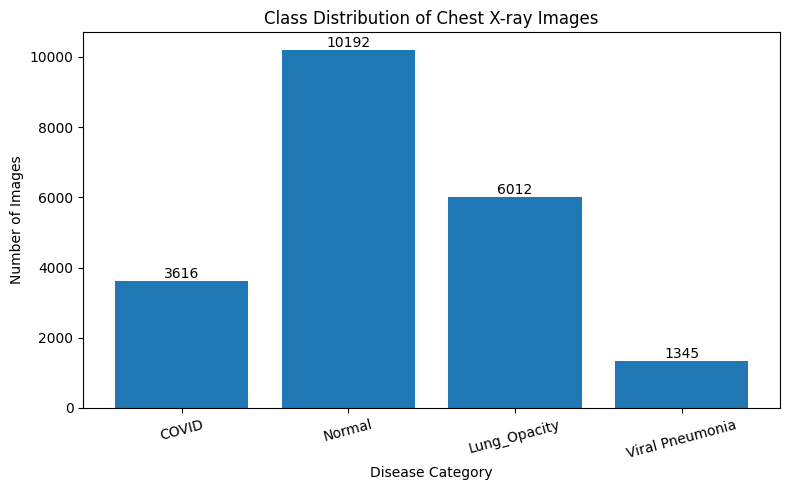

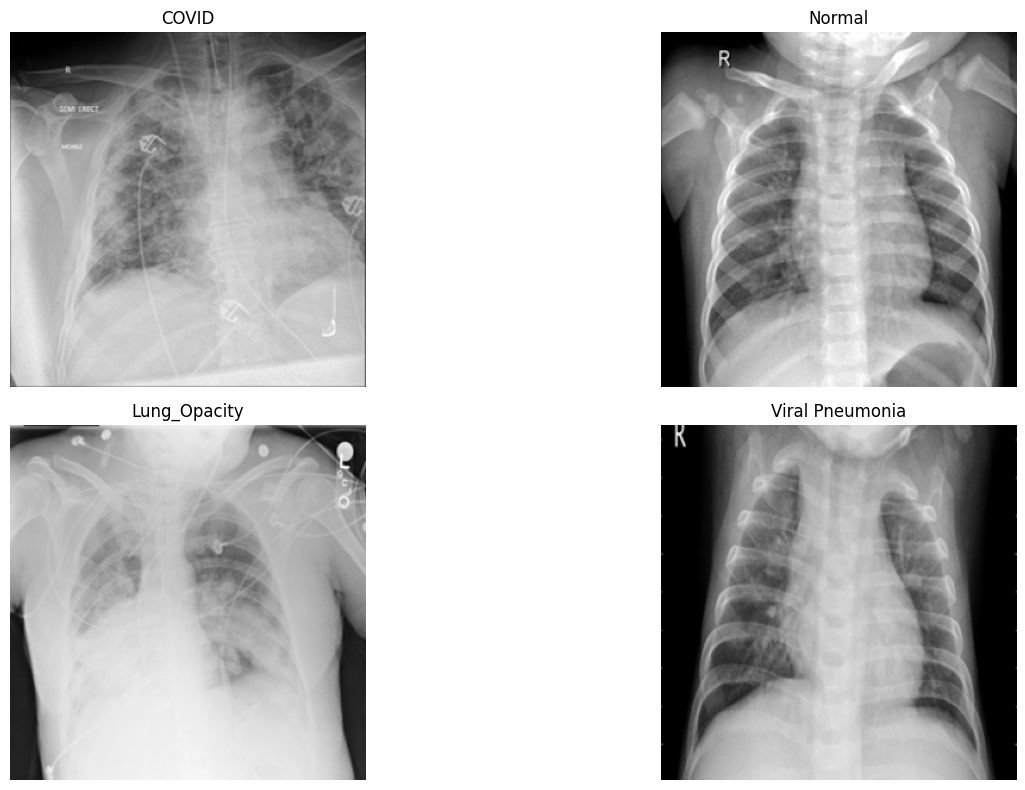

IMAGE PROPERTIES
Image Format : PNG
Image Size   : (299, 299)
Image Mode   : L
DATASET SUMMARY
Total Classes : 4
Total Images  : 21165
Image Format  : PNG
Image Size    : 299 x 299
Masks         : Available
GPU Available : True

Notebook 01 Completed Successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
import shutil
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

print("="*60)
print("TensorFlow Version :", tf.__version__)
print("GPU :", tf.config.list_physical_devices('GPU'))
print("="*60)

# ==========================================================
# PROJECT CONFIGURATION
# ==========================================================

PROJECT_PATH = "/content/drive/MyDrive/Covid_Major_Project"

ZIP_FILE = os.path.join(PROJECT_PATH, "dataset", "archive.zip")

TEMP_DATASET = "/content/COVID19_Dataset"

print("ZIP Exists :", os.path.exists(ZIP_FILE))

if os.path.exists(ZIP_FILE):
    print("ZIP Size (MB):",
          round(os.path.getsize(ZIP_FILE)/(1024*1024),2))

# ==========================================================
# EXTRACT DATASET
# ==========================================================

if os.path.exists(TEMP_DATASET):
    shutil.rmtree(TEMP_DATASET)

os.makedirs(TEMP_DATASET, exist_ok=True)

print("Extracting dataset...")
print("Please wait...")

with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(TEMP_DATASET)

print("\nExtraction Completed Successfully!")

DATASET_PATH = os.path.join(
    TEMP_DATASET,
    "COVID-19_Radiography_Dataset"
)

print(DATASET_PATH)
print()

print(os.listdir(DATASET_PATH))

# ==========================================================
# DATASET VALIDATION
# ==========================================================

required_classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

print("=" * 60)
print("DATASET VALIDATION")
print("=" * 60)

for cls in required_classes:

    class_path = os.path.join(DATASET_PATH, cls)

    if not os.path.exists(class_path):
        raise Exception(f"{cls} folder missing!")

    image_folder = os.path.join(class_path, "images")
    mask_folder = os.path.join(class_path, "masks")

    print(f"\n{cls}")

    print("✓ Images Folder :", os.path.exists(image_folder))
    print("✓ Masks Folder  :", os.path.exists(mask_folder))

print("\n✅ Dataset Validation Successful")

# ==========================================================
# IMAGE COUNT
# ==========================================================

summary = []

for cls in required_classes:

    image_folder = os.path.join(DATASET_PATH, cls, "images")

    count = len([
        f for f in os.listdir(image_folder)
        if f.lower().endswith(".png")
    ])

    summary.append([cls, count])

df = pd.DataFrame(summary, columns=["Class", "Images"])

display(df)

print("\nTotal Images :", df["Images"].sum())

# ==========================================================
# CLASS DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

bars = plt.bar(df["Class"], df["Images"])

plt.title("Class Distribution of Chest X-ray Images")

plt.xlabel("Disease Category")

plt.ylabel("Number of Images")

plt.xticks(rotation=15)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 80,
        int(bar.get_height()),
        ha='center',
        fontsize=10
    )

plt.tight_layout()

plt.show()

# ==========================================================
# DISPLAY SAMPLE IMAGES
# ==========================================================

plt.figure(figsize=(16,8))

for i, cls in enumerate(required_classes):

    image_folder = os.path.join(DATASET_PATH, cls, "images")

    image_name = random.choice(os.listdir(image_folder))

    image_path = os.path.join(image_folder, image_name)

    image = Image.open(image_path)

    plt.subplot(2,2,i+1)

    plt.imshow(image, cmap="gray")

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

# ==========================================================
# IMAGE PROPERTIES
# ==========================================================

print("="*50)
print("IMAGE PROPERTIES")
print("="*50)

sample = os.path.join(
    DATASET_PATH,
    "COVID",
    "images",
    os.listdir(os.path.join(DATASET_PATH,"COVID","images"))[0]
)

img = Image.open(sample)

print("Image Format :", img.format)
print("Image Size   :", img.size)
print("Image Mode   :", img.mode)

# ==========================================================
# DATASET SUMMARY
# ==========================================================

print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(f"Total Classes : {len(required_classes)}")
print(f"Total Images  : {df['Images'].sum()}")
print(f"Image Format  : PNG")
print(f"Image Size    : 299 x 299")
print(f"Masks         : Available")
print(f"GPU Available : {len(tf.config.list_physical_devices('GPU'))>0}")

print("\nNotebook 01 Completed Successfully.")